In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install -q scikit-learn matplotlib tqdm tf-keras

import os, pickle, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, classification_report
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Kiểm tra đường dẫn
DRIVE_ROOT = '/content/drive/MyDrive/DACN'
if os.path.exists('/content/drive/MyDrive'):
    os.makedirs(DRIVE_ROOT, exist_ok=True)
    print("Kết nối Drive thành công!")
else:
    print("Chưa tìm thấy thư mục MyDrive. Hãy kiểm tra lại bước Mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kết nối Drive thành công!


In [ ]:
DRIVE_ROOT  = '/content/drive/MyDrive/DACN'
PKL_DIR     = f'{DRIVE_ROOT}/models/precomputed'
OUTPUT_DIR  = '/tmp/mlp_results' # Reverted to local temporary directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Noi dung PKL_DIR:', os.listdir(PKL_DIR))
print(f'OUTPUT_DIR được đặt là: {OUTPUT_DIR}')

Noi dung PKL_DIR: ['Facenet_mtcnn_embeddings.pkl', 'Facenet_retinaface_embeddings.pkl', 'Facenet512_mtcnn_embeddings.pkl', 'Facenet512_retinaface_embeddings.pkl']
OUTPUT_DIR được đặt là: /tmp/mlp_results


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CELL 2: GIẢI NÉN DATASET (chỉ cần pairs.txt + ảnh để remap)
LOCAL_DATASET = '/content/lfw_funneled'
PAIRS_FILE    = f'{LOCAL_DATASET}/pairs.txt'

if os.path.exists(PAIRS_FILE):
    print('Dataset da o local.')
else:
    import subprocess
    RAR = f'{DRIVE_ROOT}/lfw_funneled.rar'
    if os.path.exists(RAR):
        subprocess.run(['apt-get','install','-qq','unrar'], check=True)
        subprocess.run(['unrar','x','-y', RAR, '/content/'], check=True)
    else:
        raise FileNotFoundError('Khong tim thay RAR hoac dataset!')

DATASET_DIR = LOCAL_DATASET
assert os.path.exists(PAIRS_FILE)
print('pairs.txt:', PAIRS_FILE)

Dataset da o local.
pairs.txt: /content/lfw_funneled/pairs.txt


In [ ]:
# CELL 3: ĐỌC PAIRS.TXT & CÁC HÀM TIỆN ÍCH
def load_pairs(pf, dd):
    pairs = []
    with open(pf) as f: lines = f.read().strip().splitlines()
    nf, np_ = int(lines[0].split()[0]), int(lines[0].split()[1])
    idx = 1
    for _ in range(nf):
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            nm,i,j = p[0],int(p[1]),int(p[2])
            p1=os.path.join(dd,nm,f'{nm}_{i:04d}.jpg')
            p2=os.path.join(dd,nm,f'{nm}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,1))
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            n1,i,n2,j = p[0],int(p[1]),p[2],int(p[3])
            p1=os.path.join(dd,n1,f'{n1}_{i:04d}.jpg')
            p2=os.path.join(dd,n2,f'{n2}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,0))
    sm=sum(l==1 for _,_,l in pairs)
    print(f'{len(pairs)} pairs (same={sm}, diff={len(pairs)-sm})')
    return pairs


In [ ]:
pairs = load_pairs(PAIRS_FILE, DATASET_DIR)
all_results = []
print('San sang!')

5996 pairs (same=2998, diff=2998)
San sang!


In [ ]:
def load_pkl_remap(pkl_path, new_base):
    """Load PKL và remap Windows paths sang Colab paths."""
    with open(pkl_path,'rb') as f: raw = pickle.load(f)
    remapped = {}
    for k, v in raw.items():
        # Lay phan tu "lfw_funneled/..." tro di
        k_norm = k.replace("\\", "/")
        if "lfw_funneled/" in k_norm:
            rel = k_norm.split("lfw_funneled/",1)[1]
            new_key = os.path.join(new_base, rel)
        else:
            new_key = k  # giu nguyen neu khong match
        remapped[new_key] = np.array(v)
    print(f'Loaded {len(remapped)} embeddings tu {os.path.basename(pkl_path)}')
    return remapped

In [ ]:
def build_features(pairs, emb_dict):
    X, y = [], []
    for p1,p2,lbl in pairs:
        e1,e2 = emb_dict.get(p1), emb_dict.get(p2)
        if e1 is None or e2 is None: continue
        if np.sum(e1)==0 or np.sum(e2)==0: continue
        X.append(np.abs(e1-e2)); y.append(lbl)
    return np.array(X), np.array(y)

In [ ]:
def build_mlp(dim):
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(128, activation='relu'), layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

In [ ]:
def compute_eer(yt, ys):
    ths=np.linspace(0,1,500); fl,rl=[],[]
    for t in ths:
        yp=(ys>=t).astype(int)
        fp=np.sum((yp==1)&(yt==0)); tn=np.sum((yp==0)&(yt==0))
        fn=np.sum((yp==0)&(yt==1)); tp=np.sum((yp==1)&(yt==1))
        fl.append(fp/(fp+tn+1e-9)); rl.append(fn/(fn+tp+1e-9))
    far,frr=np.array(fl),np.array(rl)
    idx=np.argmin(np.abs(far-frr))
    return (far[idx]+frr[idx])/2, ths[idx], ths, far, frr

In [ ]:
def run_mlp_from_pkl(pairs, pkl_path, model_name, detector, output_dir, epochs=16):
    tag = f'{model_name}_{detector}'
    od  = os.path.join(output_dir, tag)
    os.makedirs(od, exist_ok=True)
    print(f'\n{"="*55}\n CHAY: {tag}\n{"="*55}')

    # Run model logic
    hist, yte_raw, ys_raw, \
    tra, tea, trl, tel, \
    prec, rec, f1v, \
    eer, eer_t, ths, far, frr, \
    infer_avg_s, y_true, y_pred = run_mlp_model_logic(pairs, pkl_path, DATASET_DIR, epochs=epochs)

    # Calculate FAR and FRR at EER threshold for reporting
    ei=np.argmin(np.abs(ths-eer_t))
    far_at_eer = far[ei]
    frr_at_eer = frr[ei]

    # Visualize results
    visualize_mlp_results(hist, ths, far, frr, eer, eer_t, tag, od)

    # Plot confusion matrix
    plot_confusion_matrix(y_true, y_pred, classes=['different', 'same'], output_path=od)

    # Generate and print classification report
    report = classification_report(y_true, y_pred, target_names=['different', 'same'], zero_division=0)
    print('\n--- CLASSIFICATION REPORT ---\n')
    print(report)
    with open(os.path.join(od, 'classification_report.txt'), 'w', encoding='utf-8') as f: f.write(report)

    # Save report
    save_mlp_report(model_name, detector, tra, tea, trl, tel, prec, rec, f1v, eer, eer_t, far_at_eer, frr_at_eer, infer_avg_s, od)

    return {'model':tag,'train_acc':round(tra,4),'test_acc':round(tea,4),
            'precision':round(prec,4),'recall':round(rec,4),'f1':round(f1v,4),
            'eer':round(eer,4),'threshold':round(float(eer_t),4),
            'train_loss':round(trl,4),'test_loss':round(tel,4),
            'infer_avg_s':round(infer_avg_s,6)}

In [ ]:
def run_mlp_model_logic(pairs, pkl_path, dataset_dir, epochs=16):
    """Encapsulates data loading, feature building, MLP training, and evaluation."""

    # Load & remap PKL
    emb_dict = load_pkl_remap(pkl_path, dataset_dir)

    # Build features
    X, y = build_features(pairs, emb_dict)
    print(f'Features: {X.shape}')

    # Train/Test split
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

    # Train MLP
    mlp = build_mlp(Xtr.shape[1])
    cb  = keras.callbacks.EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)
    hist = mlp.fit(Xtr,ytr,epochs=epochs,batch_size=64,
                   validation_split=0.15,callbacks=[cb],verbose=1)

    # Evaluate
    t0=time.time(); ys=mlp.predict(Xte,verbose=0).flatten(); tit=time.time()-t0
    yp=(ys>=0.5).astype(int)
    trl,tra=mlp.evaluate(Xtr,ytr,verbose=0)
    tel,tea=mlp.evaluate(Xte,yte,verbose=0)
    prec=precision_score(yte,yp,zero_division=0)
    rec=recall_score(yte,yp,zero_division=0)
    f1v=f1_score(yte,yp,zero_division=0)
    eer,eer_t,ths,far,frr=compute_eer(yte,ys)

    infer_avg_s = tit / len(Xte)

    return (
        hist, yte, ys,
        tra, tea, trl, tel,
        prec, rec, f1v,
        eer, eer_t, ths, far, frr,
        infer_avg_s, yte, yp
    )

In [ ]:
def visualize_mlp_results(hist, ths, far, frr, eer, eer_t, tag, output_path):

    epochs = range(1, len(hist.history['accuracy']) + 1)

    # =======================
    # 1. ACCURACY (IMPROVED)
    # =======================
    plt.figure(figsize=(12, 7))

    train_acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']

    plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy', linewidth=2, markersize=7)
    plt.plot(epochs, val_acc, 'rs-', label='Validation Accuracy', linewidth=2, markersize=7)

    for i in range(len(epochs)):
        plt.annotate(f'{train_acc[i]:.2f}',
                     (epochs[i], train_acc[i]),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center',
                     color='blue',
                     fontsize=8,
                     fontweight='bold')

        plt.annotate(f'{val_acc[i]:.2f}',
                     (epochs[i], val_acc[i]),
                     textcoords="offset points",
                     xytext=(0, -15),
                     ha='center',
                     color='red',
                     fontsize=8,
                     fontweight='bold')

    plt.title(f'{tag} — Accuracy per Epoch', fontsize=15, pad=20)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.xticks(epochs)
    plt.ylim(min(val_acc) - 0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'accuracy.png'), dpi=150)
    plt.show()
    plt.close()

    # =======================
    # 2. LOSS (IMPROVED)
    # =======================
    plt.figure(figsize=(12, 7))

    train_loss = hist.history['loss']
    val_loss = hist.history['val_loss']

    plt.plot(epochs, train_loss, 'go-', label='Training Loss', linewidth=2, markersize=7)
    plt.plot(epochs, val_loss, 'mo-', label='Validation Loss', linewidth=2, markersize=7)

    for i in range(len(epochs)):
        plt.annotate(f'{train_loss[i]:.2f}',
                     (epochs[i], train_loss[i]),
                     textcoords="offset points",
                     xytext=(0, -15),
                     ha='center',
                     color='green',
                     fontsize=8,
                     fontweight='bold')

        plt.annotate(f'{val_loss[i]:.2f}',
                     (epochs[i], val_loss[i]),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center',
                     color='purple',
                     fontsize=8,
                     fontweight='bold')

    plt.title(f'{tag} — Loss per Epoch', fontsize=15, pad=20)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xticks(epochs)
    plt.ylim(0, max(val_loss) + 0.2)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'loss.png'), dpi=150)
    plt.show()
    plt.close()

    # =======================
    # 3. FAR / FRR (GIỮ NGUYÊN)
    # =======================
    plt.figure(figsize=(8,5))
    plt.plot(ths, far, label='FAR', color='steelblue')
    plt.plot(ths, frr, label='FRR', color='orange')
    plt.axvline(x=eer_t, color='red', linestyle='--', label=f'EER:{eer:.4f}')

    plt.title(f'{tag} — FAR vs FRR')
    plt.xlabel('Threshold')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'far_frr.png'), dpi=150)
    plt.show()
    plt.close()

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, classes, output_path, normalize=True):
    """
    y_true: ground truth labels
    y_pred: predicted labels
    classes: list tên class
    normalize: hiển thị % hay số lượng
    """

    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion Matrix', fontsize=14)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Hiển thị số trong từng ô
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text = f"{value:.2f}" if normalize else f"{int(value)}"

            plt.text(j, i, text,
                     ha="center", va="center",
                     color="white" if value > cm.max()/2 else "black",
                     fontsize=10,
                     fontweight='bold')

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    plt.savefig(f"{output_path}/confusion_matrix.png", dpi=150)
    plt.show()
    plt.close()

In [ ]:
def save_mlp_report(model_name, detector, tra, tea, trl, tel, prec, rec, f1v, eer, eer_t, far_at_eer, frr_at_eer, infer_avg_s, output_path):
    """Writes the evaluation report to a text file."""

    rpt=(
        "--- BAO CAO KET QUA NHAN DIEN ---\n"
        f"Model: {model_name} | Detector: {detector}\n"
        f"EER dat duoc: {eer:.4f} tai Threshold: {eer_t:.4f}\n"
        f"Train Accuracy: {tra:.4f}\nTest Accuracy:  {tea:.4f}\n"
        f"Train Loss: {trl:.4f}\nTest Loss:  {tel:.4f}\n"
        f"Precision: {prec:.4f}\nRecall: {rec:.4f}\nF1-Score: {f1v:.4f}\n"
        f"FAR tai EER: {far_at_eer:.4f}\nFRR tai EER: {frr_at_eer:.4f}\n"
        f"TB predict/anh: {infer_avg_s:.4f}s\n"
    )
    print(rpt)
    with open(os.path.join(output_path,'final_report.txt'),'w',encoding='utf-8') as f: f.write(rpt)


 CHAY: Facenet_mtcnn
Loaded 7701 embeddings tu Facenet_mtcnn_embeddings.pkl
Features: (5996, 128)
Epoch 1/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.8842 - loss: 0.2838 - val_accuracy: 0.4972 - val_loss: 2.7531
Epoch 2/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9212 - loss: 0.2024 - val_accuracy: 0.6583 - val_loss: 1.0333
Epoch 3/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9325 - loss: 0.1829 - val_accuracy: 0.8014 - val_loss: 0.5441
Epoch 4/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9377 - loss: 0.1721 - val_accuracy: 0.8806 - val_loss: 0.3294
Epoch 5/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9372 - loss: 0.1649 - val_accuracy: 0.9125 - val_loss: 0.2532
Epoch 6/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9374 - loss: 0.1551 - val_accuracy: 0.9111 - val_loss: 0.2451
Epoch 7/16
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9426 - loss: 0.1543 - val_accuracy: 0.9153 - val_loss: 0.2253
Epoch 8/16
64/64 

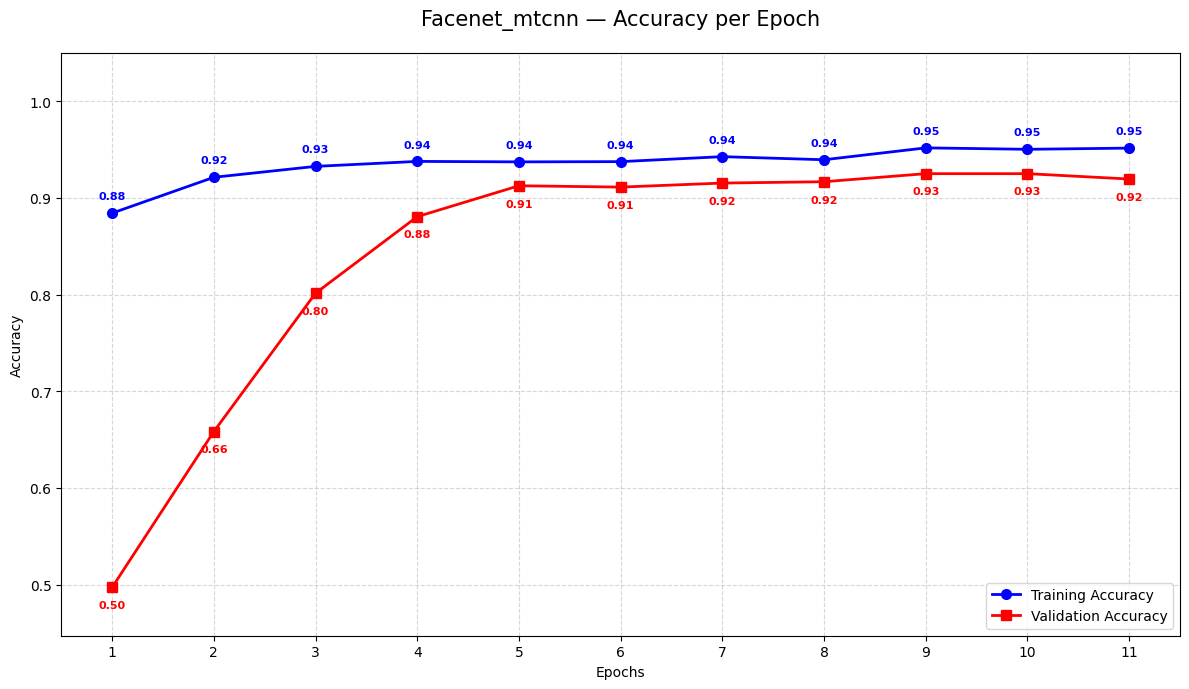

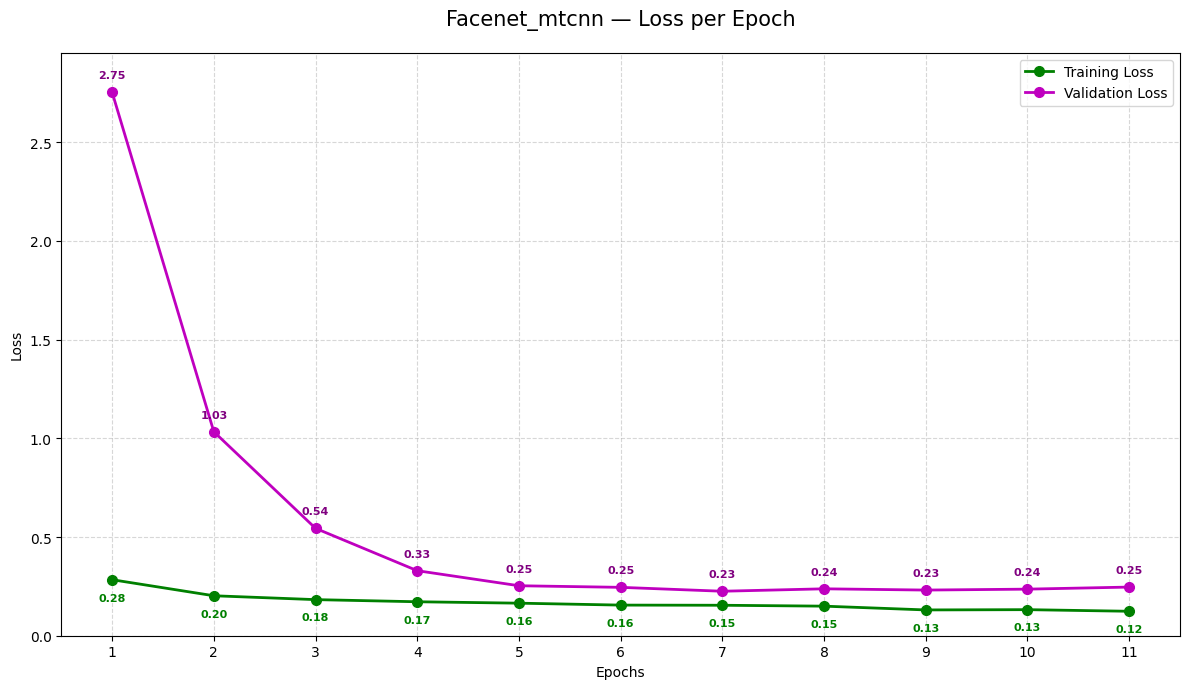

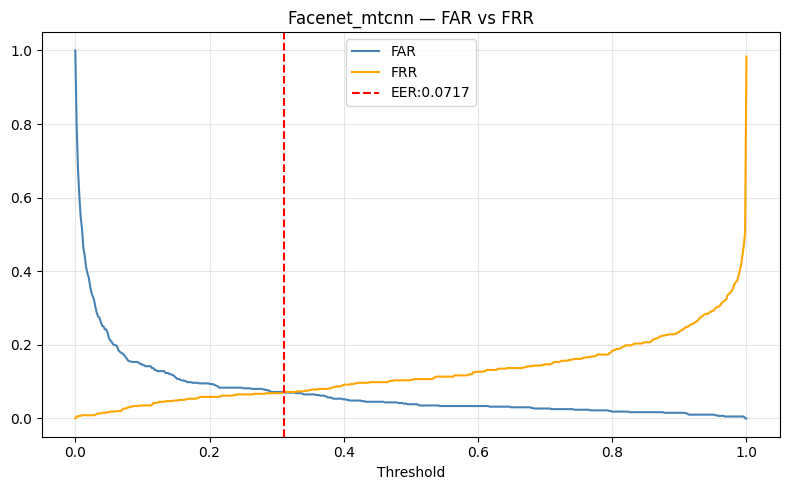

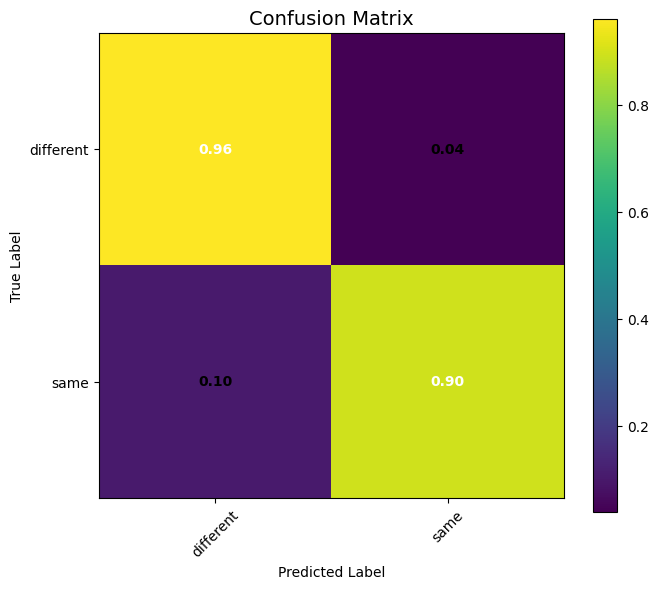


--- CLASSIFICATION REPORT ---

              precision    recall  f1-score   support

   different       0.90      0.96      0.93       600
        same       0.96      0.90      0.93       600

    accuracy                           0.93      1200
   macro avg       0.93      0.93      0.93      1200
weighted avg       0.93      0.93      0.93      1200

--- BAO CAO KET QUA NHAN DIEN ---
Model: Facenet | Detector: mtcnn
EER dat duoc: 0.0717 tai Threshold: 0.3106
Train Accuracy: 0.9450
Test Accuracy:  0.9292
Train Loss: 0.1337
Test Loss:  0.2034
Precision: 0.9590
Recall: 0.8967
F1-Score: 0.9268
FAR tai EER: 0.0717
FRR tai EER: 0.0717
TB predict/anh: 0.0011s

Model 1 xong!


In [ ]:
# CELL 4: MODEL 1 — Facenet + MTCNN (TỪ PKL)
pkl1 = os.path.join(PKL_DIR, 'Facenet_mtcnn_embeddings.pkl')
r1 = run_mlp_from_pkl(pairs, pkl1, 'Facenet', 'mtcnn', OUTPUT_DIR)
all_results.append(r1)
print('Model 1 xong!')

In [ ]:
print(f"Log files are saved in: {OUTPUT_DIR}")

Log files are saved in: /tmp/mlp_results
